# ECE 471 Sample Project



In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a project folder for EfficientAD weights
WEIGHTS_PATH = '/content/drive/MyDrive/ECE471_Project/weights'
os.makedirs(WEIGHTS_PATH, exist_ok=True)

print(f"Weights will be saved to: {WEIGHTS_PATH}")

Mounted at /content/drive
Weights will be saved to: /content/drive/MyDrive/ECE471_Project/weights


In [4]:
# Download the dataset, setup packages
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Downloading...
From: https://drive.google.com/uc?id=1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
To: /content/dataset.zip
100% 2.60M/2.60M [00:00<00:00, 16.6MB/s]


In [5]:
# Some helper functions for your project
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws', 'capsule']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision
from fastai.data.external import untar_data, URLs
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.optim as optim
torch.backends.cudnn.benchmark = True

In [40]:
class AnomalyDetector:
  def __init__(self,):
    self.model = None
  def create_model(self, dataset : np.ndarray):
    self.model = np.mean(dataset, axis=0)
    print(dataset.shape)
    plt.figure(figsize = (16,5))
    plt.imshow(self.model)
    plt.show()
  def predict(self, test_data : np.ndarray):
    return np.mean(np.square(test_data - self.model), axis=(1,2,3))

In [8]:
# Load the pretrained weights of WideResNet-101 trained on ImageNet
# This will act as the truth from which the teacher network will learn
oracle = models.wide_resnet101_2(weights='IMAGENET1K_V1')
# Set to evaluation mode as we are not training it, just using it.
oracle.eval()

# Freeze all of the oracle's weight values
for param in oracle.parameters():
  param.requires_grad = False

# Switch to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

oracle.to(device)

print(f"WideResNet-101 loaded and frozen on {device}.")

Downloading: "https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet101_2-32ee1156.pth


100%|██████████| 243M/243M [00:01<00:00, 226MB/s]


WideResNet-101 loaded and frozen on cuda.


In [9]:
# Get the Imagenette images
# Imagenette is a labelled subset of ImagNet
path = untar_data(URLs.IMAGENETTE)

distillation_data_path = os.path.join(path, 'train')

<div><progress max="1557161267" value="1557168128"></progress> 100.00% [1557168128/1557161267 00:34&lt;00:00]</div>

In [10]:
class OracleWrapper(nn.Module):
  def __init__(self, backbone):
    super(OracleWrapper, self).__init__()
    self.backbone = backbone

    self.layer2 = backbone.layer2
    self.layer3 = backbone.layer3

  def forward(self, x):

    # Initialize layers of WideResNet
    x = self.backbone.conv1(x)
    x = self.backbone.bn1(x)
    x = self.backbone.relu(x)
    x = self.backbone.maxpool(x)
    x = self.backbone.layer1(x)

    # We want to extract intermediate features as done in the EfficientAD paper
    f2 = self.layer2(x)
    f3 = self.layer3(f2)

    # Resize such that both layers are 64x64 so they can be combined
    f2 = F.interpolate(f2, size=(64, 64), mode='bilinear', align_corners=False)
    f3 = F.interpolate(f3, size=(64, 64), mode='bilinear', align_corners=False)
    # Combine the 512 and 1024 channels into one block of size 1536
    combined = torch.cat([f2, f3], dim=1)
    # Project this down to 384 channels as required by EfficientAD
    # We take the first 384 channels as these should have the most information
    projected = combined[:, :384, :, :]

    return projected

oracle_extractor = OracleWrapper(oracle).to(device)




In [53]:
# Get dataset statistics to save and use later
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# distill_dataset = datasets.ImageFolder(root=os.path.join(path, 'train'), transform=transform)
# distill_loader = DataLoader(distill_dataset, batch_size=1, shuffle=True)

# distill_images, _ = next(iter(distill_loader))
# distill_images = distill_images.to(device)

distill_dataset = datasets.ImageFolder(root=os.path.join(path, 'train'), transform=transform)
distill_loader = DataLoader(distill_dataset, batch_size=len(distill_dataset), shuffle=False)

distill_images, _ = next(iter(distill_loader))
distill_images = distill_images.to(device)


In [12]:
channel_values = [[] for _ in range(384)]
num_images_to_sample = 500

with torch.no_grad():
  for i, (images, _) in enumerate(distill_loader):

    if i >= num_images_to_sample:
      break

    images = images.to(device)
    features = oracle_extractor(images)

    for c in range(384):

      channel_values[c].append(features[0, c].cpu().numpy().flatten())

    if i % 50 == 0:
      print(f"Processed {i}/{num_images_to_sample} images...")

oracle_mean = torch.zeros(384).to(device)
oracle_variance = torch.zeros(384).to(device)

for c in range(384):
  all_values = np.concatenate(channel_values[c])
  oracle_mean[c] = torch.tensor(np.mean(all_values))
  oracle_variance[c] = torch.tensor(np.std(all_values))
  print(f"saved mean and variance {c} / 384")

print(f"Mean shape: {oracle_mean.shape}") # Should be [384]
print(f"Variance shape: {oracle_variance.shape}") # Should be [384]
print(f"First 5 means: {oracle_mean[:5]}")

# Save to Drive
torch.save({'mu': oracle_mean, 'sigma': oracle_variance},
           os.path.join(WEIGHTS_PATH, 'oracle_stats.pth'))

Processed 0/500 images...
Processed 50/500 images...
Processed 100/500 images...
Processed 150/500 images...
Processed 200/500 images...
Processed 250/500 images...
Processed 300/500 images...
Processed 350/500 images...
Processed 400/500 images...
Processed 450/500 images...
saved mean and variance 0 / 384
saved mean and variance 1 / 384
saved mean and variance 2 / 384
saved mean and variance 3 / 384
saved mean and variance 4 / 384
saved mean and variance 5 / 384
saved mean and variance 6 / 384
saved mean and variance 7 / 384
saved mean and variance 8 / 384
saved mean and variance 9 / 384
saved mean and variance 10 / 384
saved mean and variance 11 / 384
saved mean and variance 12 / 384
saved mean and variance 13 / 384
saved mean and variance 14 / 384
saved mean and variance 15 / 384
saved mean and variance 16 / 384
saved mean and variance 17 / 384
saved mean and variance 18 / 384
saved mean and variance 19 / 384
saved mean and variance 20 / 384
saved mean and variance 21 / 384
saved m

In [13]:
class AutoEncoder(nn.Module):
  def __init__(self,):
    super().__init__()

    # Encoder Layers as class attributes. Conv2d docs:
    # https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
    # Input channels is what the layer receives, and output channels is
    # specified in table 8 of the paper.
    # Kernel size, stride, and padding all taken directly from table 8
    self.EncConv1 = nn.Conv2d(in_channels=3, out_channels=32,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv2 = nn.Conv2d(in_channels=32, out_channels=32,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv3 = nn.Conv2d(in_channels=32, out_channels=64,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv4 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv5 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(2, 2), padding=1)
    self.EncConv6 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(8, 8), stride=(1, 1), padding=0)

    # Decoder layers (more Conv2D)
    self.DecConv1 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv2 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv3 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv4 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv5 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv6 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(4, 4), stride=(1, 1), padding=2)
    self.DecConv7 = nn.Conv2d(in_channels=64, out_channels=64,
                              kernel_size=(3, 3), stride=(1, 1), padding=1)
    self.DecConv8 = nn.Conv2d(in_channels=64, out_channels=384,
                              kernel_size=(3, 3), stride=(1, 1), padding=1)

    # Bilinear Layers: https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html
    self.Bilinear1 = nn.Upsample(size=(3, 3), mode="bilinear")
    self.Bilinear2 = nn.Upsample(size=(8, 8), mode="bilinear")
    self.Bilinear3 = nn.Upsample(size=(15, 15), mode="bilinear")
    self.Bilinear4 = nn.Upsample(size=(32, 32), mode="bilinear")
    self.Bilinear5 = nn.Upsample(size=(63, 63), mode="bilinear")
    self.Bilinear6 = nn.Upsample(size=(127, 127), mode="bilinear")
    self.Bilinear7 = nn.Upsample(size=(64, 64), mode="bilinear")

    # Dropout Layers: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html
    self.Dropout1To6 = nn.Dropout(p=0.2) # All dropout layers have the same p value

    # Relu activation function (for convenience)
    self.relu = nn.ReLU()

  def forward(self, x):
    # Compute a forward pass. Here we just combine the layers in the order of table 8 in the EfficientAD paper
    out = self.relu(self.EncConv1(x))
    out = self.relu(self.EncConv2(out))
    out = self.relu(self.EncConv3(out))
    out = self.relu(self.EncConv4(out))
    out = self.relu(self.EncConv5(out))
    out = self.EncConv6(out)

    out = self.Bilinear1(out)

    out = self.relu(self.DecConv1(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear2(out)

    out = self.relu(self.DecConv2(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear3(out)

    out = self.relu(self.DecConv3(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear4(out)

    out = self.relu(self.DecConv4(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear5(out)

    out = self.relu(self.DecConv5(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear6(out)

    out = self.relu(self.DecConv6(out))
    out = self.Dropout1To6(out)
    out = self.Bilinear7(out)

    out = self.relu(self.DecConv7(out))
    out = self.DecConv8(out)

    return out

In [42]:
class PDN(nn.Module):
  def __init__(self, out_channels=384, padding=True):
    super(PDN, self).__init__()

    p = 3 if padding else 0

    self.conv1 = nn.Conv2d(3, 128, kernel_size=4, stride=1, padding=p);
    self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1);
    self.conv2 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=p);
    self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1);
    self.conv3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1);
    self.conv4 = nn.Conv2d(256, out_channels, kernel_size=4, stride=1, padding=0);

    self.relu = nn.ReLU(inplace=True);

    # Compute the forward pass
  def forward(self, x):
    x = self.relu(self.conv1(x))
    x = self.avgpool1(x)
    x = self.relu(self.conv2(x))
    x = self.avgpool2(x)
    x = self.relu(self.conv3(x))
    x = self.conv4(x)
    return x

In [15]:
# We use this helper to calculate the mean squared error
# This method is described in Section 3.1 and Algorithm 3 of the EfficientAD paper
def distillation_loss(teacher_output, oracle_output, mu, sigma):

  # Reshape mu and sigma
  mu = mu.view(1, -1, 1, 1)
  sigma = sigma.view(1, -1, 1, 1)
  # Normalize the oracle output
  normalized_oracle = (oracle_output - mu) / sigma
  # Compute the loss
  loss = torch.mean((teacher_output - normalized_oracle) ** 2)

  return loss

In [61]:
def train_teacher(teacher, oracle_extractor, distill_images, oracle_mean, oracle_variance, iterations=15000, batch_size=16):
    teacher.train()
    oracle_extractor.eval()

    # Algorithm 3, Line 13: Adam with lr=1e-4 and weight_decay=1e-5
    optimizer = optim.Adam(teacher.parameters(), lr=1e-4, weight_decay=1e-5)

    # data_iter = iter(distill_loader)
    mu = oracle_mean.view(1, -1, 1, 1).to(device)
    sigma = oracle_variance.view(1, -1, 1, 1).to(device)

    # Algorithm 3, Lines 14-30: Main training loop
    for iteration in range(1, iterations + 1):

        # Algorithm 3, Line 15: Initialize batch loss
        # L_batch = 0.0

        # Algorithm 3, Lines 16-27: Inner batch loop of 16 images
        # We dont actually need to loop, can process the whole batch at once which is more
        # efficient and does the same thing
        indices = torch.randint(0, len(distill_images), (batch_size,), device=distill_images.device)
        images = distill_images[indices]

        # for batch_idx in range(batch_size):

        # # Algorithm 3, Line 17: Choose a random training image
        # try:
        #     image, _ = next(data_iter)
        # except StopIteration:
        #     data_iter = iter(distill_loader)
        #     image, _ = next(data_iter)

        # image = image.to(device)  # Shape: [1, 3, 256, 256]

        # Algorithm 3, Line 18: Convert to grayscale with probability 0.1
        # if np.random.random() < 0.1:
        #     gray = transforms.functional.rgb_to_grayscale(image, num_output_channels=3)
        #     image = gray

        gray = transforms.functional.rgb_to_grayscale(images, num_output_channels=3)
        gray_mask = (torch.rand(images.shape[0], 1, 1,1, device=device) < 0.1)
        images = torch.where(gray_mask, gray, images)

        # Algorithm 3, Line 19: Images are already resized to 256x256 by the dataloader
        # but we need a 512x512 version for the oracle
        images_oracle = F.interpolate(images, size=(512, 512), mode='bilinear', align_corners=False)

        # Algorithm 3, Lines 21-22: Get normalized oracle features
        with torch.no_grad():
          y_oracle = oracle_extractor(images_oracle)

          # Normalize oracle output (Algorithm 3, Line 22)
          # mu = oracle_mean.view(1, -1, 1, 1).to(device)
          # sigma = oracle_variance.view(1, -1, 1, 1).to(device)
          y_oracle_normalized = (y_oracle - mu) / sigma

        # Algorithm 3, Line 23: Get teacher features on 256x256 image
        y_teacher = teacher(images)

        # Algorithm 3, Lines 24-25: Compute squared difference and mean loss
        D_dist = (y_oracle_normalized - y_teacher) ** 2
        L_batch = D_dist.mean()

        # Algorithm 3, Line 26: Accumulate batch loss
        # L_batch += L_dist

        # End of Pseudocode loop

        # Algorithm 3, Line 28: Average over batch
        # L_batch = L_batch / batch_size

        # Algorithm 3, Line 29: Update teacher parameters
        optimizer.zero_grad()
        L_batch.backward()
        optimizer.step()

        if iteration % 1000 == 0:
            print(f"Iteration {iteration}/{iterations} | Loss: {L_batch.item():.6f}")
            # Save teacher weights periodically during training
            teacher.eval()
            torch.save(teacher.state_dict(), os.path.join(WEIGHTS_PATH, 'teacher_overnight.pth'))
            print("Teacher weights saved.")
            # After saving put teacher back in training mode
            teacher.train()

In [62]:
teacher = PDN().to(device)
distill_loader = DataLoader(distill_dataset, batch_size=16, shuffle=True, drop_last=True)


In [63]:
# teacher = PDN(out_channels=384).to(device)
# train_teacher(teacher, oracle_extractor, distill_loader, oracle_mean, oracle_variance)
# torch.save(teacher.state_dict(), os.path.join(WEIGHTS_PATH, 'teacher_overnight.pth'))

teacher = PDN(out_channels=384).to(device)
train_teacher(teacher, oracle_extractor, distill_images, oracle_mean, oracle_variance)
torch.save(teacher.state_dict(), os.path.join(WEIGHTS_PATH, 'teacher_overnight.pth'))

Iteration 1000/15000 | Loss: 0.796683
Teacher weights saved.
Iteration 2000/15000 | Loss: 0.741985
Teacher weights saved.
Iteration 3000/15000 | Loss: 0.643756
Teacher weights saved.
Iteration 4000/15000 | Loss: 0.537800
Teacher weights saved.
Iteration 5000/15000 | Loss: 0.587417
Teacher weights saved.
Iteration 6000/15000 | Loss: 0.564855
Teacher weights saved.
Iteration 7000/15000 | Loss: 0.570221
Teacher weights saved.
Iteration 8000/15000 | Loss: 0.518888
Teacher weights saved.
Iteration 9000/15000 | Loss: 0.414351
Teacher weights saved.


KeyboardInterrupt: 

In [36]:
PROJECT_WEIGHTS_PATH = '/content/drive/MyDrive/ECE471_Project/weights'
file_name = 'teacher.pth'
full_save_path = os.path.join(PROJECT_WEIGHTS_PATH, file_name)

# Save weights to teacher, set to evaluation mode and disable gradients (freeze teacher)
torch.save(teacher.state_dict(), full_save_path)
teacher.load_state_dict(torch.load(full_save_path))
teacher.eval()
for param in teacher.parameters():
  param.requires_grad = False

In [20]:
def HWC_to_NCHW(img, augment=False):
  img = torch.tensor(img, dtype=torch.float32)
  img = img.permute(2, 0, 1) # Reorder dims
  img = transforms.Resize((256, 256))(img) # Match expected input of the network
  if augment:
        # Horizontal flip
        if np.random.random() > 0.5:
            img = transforms.functional.hflip(img)
        # Vertical flip
        if np.random.random() > 0.5:
            img = transforms.functional.vflip(img)
        # Minor rotation (+/- 10 degrees) to handle slight misalignment
        angle = np.random.uniform(-10, 10)
        img = transforms.functional.rotate(img, angle)
  img = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(img) # Match mean and stdev of ImageNet
  img = img.unsqueeze(0) # Add batch dim (N)
  return img

In [21]:
def image_preprocessing(images_np, device):
  img = torch.tensor(images_np, dtype=torch.float32)
  img = img.permute(0, 3, 1, 2).contiguous()
  img = torch.nn.functional.interpolate(img, size=(256, 256), mode='bilinear', align_corners=False)
  img = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(img)

  return img.to(device)

In [22]:
def augment_batch(x):
  # Horizontal flip
  if np.random.random() > 0.5:
      img = transforms.functional.hflip(img)
  # Vertical flip
  if np.random.random() > 0.5:
      img = transforms.functional.vflip(img)
  # Minor rotation (+/- 10 degrees) to handle slight misalignment
  angle = np.random.uniform(-10, 10)
  img = transforms.functional.rotate(img, angle)

In [37]:
# Follow Algorithm 1 in the paper to train the autoencoder and student
# As in the paper, need pretrained teacher (we have), sequence of training/validation images (given)

def train_student_and_autoencoder(training_data, validation_data, testing_data, testing_labels):

  # 1. Compute Mu and Sigma based on training data set (Algorithm 1, Steps 3-9)
  teacher_outputs = []
  with torch.no_grad():
    for i in range(len(training_data)):
      # Prepare image and get teacher features
      img = training_data[i:i+1]
      y_prime = teacher(img) # Shape: [1, 384, 64, 64]
      teacher_outputs.append(y_prime)

  # Concatenate all outputs into one large tensor [N, 384, 64, 64]
  all_outputs = torch.cat(teacher_outputs, dim=0)

  # Compute mu and sigma per channel across the entire dataset
  # We reduce over Dim 0 (Images), Dim 2 (Height), and Dim 3 (Width)
  mu = torch.mean(all_outputs, dim=(0, 2, 3), keepdim=True)
  sigma = torch.std(all_outputs, dim=(0, 2, 3), keepdim=True)

  # Now we initialize a joint Adam optimizer for parameters of student and autoencoder (learning rate and weight decay from algorithm 1)
  lr = 3e-3
  weight_decay = 1e-5
  sa_parameters = list(student.parameters()) + list(autoencoder.parameters())
  sa_optimizer = optim.Adam(sa_parameters, lr=lr, weight_decay=weight_decay)

  # Liam's edit: Initialize pretraining iterator once, outside the main loop.
  # We don't want to create a new pretraining iterator instance with each loop iteration
  pretrain_iter = iter(distill_loader)

  batch_size = min(8, len(training_data))
  # Main training loop
  for i in range(1, 10001):
    # Choose 'random' training image, do fwd pass with teacher, do fwd pass with student.
    # Note we want image in NCHW shape form original H, W, 3
    indices = torch.randint(0, len(training_data), (batch_size,), device=training_data.device)
    # index = np.random.randint(len(training_data))
    random_image = training_data[indices]
    # random_image = HWC_to_NCHW(training_data[index]).to(device)

    with torch.no_grad():
      teacher_output = teacher(random_image)
    student_output = student(random_image)

    # Get the normalized teacher output per channel
    normalized_teacher_output = (teacher_output - mu) / sigma

    # Now compute square difference between normalized teacher output and the first 384 entries of the student output
    student_output_f384 = student_output[:, :384, :, :]
    diff_st = (normalized_teacher_output - student_output_f384)**2

    # Get the 0.999 quantile of the difference, and compute loss as mean of diff_st entries over or equal to the quantile
    diff_st_999 = torch.quantile(torch.flatten(diff_st), q=0.999)

    # Liam's edit: Replace slow python loop with pytorch boolean indexing
    loss_hard = diff_st[diff_st >= diff_st_999].mean()

    # Now choose a random pretraining ImageNet image. This is from our distill_dataset, and
    # we can make an iterator of the loader, then get next item. Shuffle=True makes this random each time
    # Liam's edit: Load pretraining images more efficiently
    # We can create an infinite loop of the image data (so that we never run out) with a try block
    # This way we don't need to create a new pretraining iterator with each loop iteration
    try:
      pretraining_image, _ = next(pretrain_iter)
    except StopIteration:
      pretrain_iter = iter(distill_loader)
      pretraining_image, _ = next(pretrain_iter)
    pretraining_image = pretraining_image.to(device)

    # Now get the student teacher loss with hard loss and a regularization term defined in the algorithm
    student_output_pretaining_384 = student(pretraining_image)[:, :384, :, :]
    reg_term = (student_output_pretaining_384**2).mean()
    loss_st = loss_hard + reg_term

    # Now we augment the training images for use on the encoder branch. We do this as we want the encoder to
    # learn more general structures. (Use adjustmented from Algorithm 1)

    # random_image = random_image[0] # CHW
    augmentation_index = np.random.randint(1, 4)
    lam = np.random.uniform(0.8, 1.2)
    if augmentation_index == 1:
      augmented_images = torchvision.transforms.functional.adjust_brightness(random_image, lam)
    elif augmentation_index == 2:
      augmented_images = torchvision.transforms.functional.adjust_contrast(random_image, lam)
    elif augmentation_index == 3:
      augmented_images = torchvision.transforms.functional.adjust_saturation(random_image, lam)

    # With the augmented training images, run forward passes on the autoencoder and the teacher,
    # and normalize as we did before.
    autoencoder_output = autoencoder(augmented_images)
    with torch.no_grad():
      teacher_output_augmented = teacher(augmented_images)

    normalized_teacher_output_augmented = (teacher_output_augmented - mu) / sigma
    student_output_augmented = student(augmented_images)
    student_output_augmented_l384 = student_output_augmented[:, 384:, :, :]
    diff_ta = (normalized_teacher_output_augmented - autoencoder_output)**2
    diff_sa = (autoencoder_output - student_output_augmented_l384)**2

    # For the loss, we take the sum of the means of each of the differences (teacher-autoencoder, student-autoencoder,
    # and the student-teacher loss from earlier)
    loss_ta = torch.mean(diff_ta)
    loss_sa = torch.mean(diff_sa)
    loss = loss_st + loss_ta + loss_sa

    if i % 500 == 0:
      print("At iteration:", i, " loss: ",  loss)

    # Update the Adam optimizer parameters. Clear old gradients (avoid accumulation), and step
    sa_optimizer.zero_grad()
    loss.backward()
    sa_optimizer.step()

    # Decay learning rate after 4500 iterations
    if i == 9300:
      sa_optimizer.param_groups[0]['lr'] = 1e-5


  # Here, the training of student and autoencoder weights is done. We now make anomaly maps
  # and get anomaly scores
  st_anomaly_scores = []
  sa_anomaly_scores = []

  student.eval()
  autoencoder.eval()
  # Use more normal images from the validation set to get high end differences in normal images
  for i in range(len(validation_data)):
    val_image = validation_data[i:i+1]

    # Get outputs and normalize/compute loss similar to before
    with torch.no_grad():
      teacher_output = teacher(val_image)
    student_output = student(val_image)
    autoencoder_output = autoencoder(val_image)

    student_output_f384 = student_output[:, :384, :, :]
    student_output_l384 = student_output[:, 384:, :, :]
    normalized_teacher_output = (teacher_output - mu) / sigma
    diff_st = (normalized_teacher_output - student_output_f384)**2
    diff_sa = (autoencoder_output - student_output_l384)**2

    # Make anomaly maps using the differences. Take mean difference across channel for each output pixel
    map_st = diff_st.mean(dim=1)
    map_sa = diff_sa.mean(dim=1)

    # Resize with bilinear interpolation (like done in the autoencoder forward pass)
    map_st = F.interpolate(input=map_st.unsqueeze(1), size=(256, 256), mode='bilinear')
    map_sa = F.interpolate(input=map_sa.unsqueeze(1), size=(256, 256), mode='bilinear')

    # Append vectorized anomaly scores to score lists
    st_anomaly_scores.append(torch.flatten(map_st))
    sa_anomaly_scores.append(torch.flatten(map_sa))

  # We now have a list of flattened local (st) anomaly maps, and global (sa)
  # Get quantile values for 0.9 and 0.995 for each map so we have a reference later for what to consider an anomaly
  st_quantile_90 = torch.quantile(torch.cat(st_anomaly_scores), 0.90)
  st_quantile_995 = torch.quantile(torch.cat(st_anomaly_scores), 0.995)

  sa_quantile_90 = torch.quantile(torch.cat(sa_anomaly_scores), 0.90)
  sa_quantile_995 = torch.quantile(torch.cat(sa_anomaly_scores), 0.995)

  return teacher, student, autoencoder, mu, sigma, st_quantile_90, st_quantile_995, sa_quantile_90, sa_quantile_995

In [38]:
# Get data for training function
pasta_training_data, pasta_testing_data_np, pasta_testing_labels = load_dataset("pasta")
screws_training_data, screws_testing_data_np, screws_testing_labels = load_dataset("screws")
capsule_training_data, capsule_testing_data_np, capsule_testing_labels = load_dataset("capsule")

n_pasta = len(pasta_training_data)
n_screws = len(screws_training_data)
n_capsule = len(capsule_training_data)

val_idx_pasta = int(n_pasta*0.8)
val_idx_screws = int(n_screws*0.8)
val_idx_capsule = int(n_capsule*0.8)

pasta_train_data_np = pasta_training_data[:val_idx_pasta]
pasta_validation_data_np = pasta_training_data[val_idx_pasta:]

screws_train_data_np = screws_training_data[:val_idx_screws]
screws_validation_data_np = screws_training_data[val_idx_screws:]

capsule_train_data_np = capsule_training_data[:val_idx_capsule]
capsule_validation_data_np = capsule_training_data[val_idx_capsule:]

# Do all preprocessing once and send it to the GPU
pasta_train = image_preprocessing(pasta_train_data_np, device)
pasta_validation = image_preprocessing(pasta_validation_data_np, device)
pasta_test = image_preprocessing(pasta_testing_data_np, device)

screws_train = image_preprocessing(screws_train_data_np, device)
screws_validation = image_preprocessing(screws_validation_data_np, device)
screws_test = image_preprocessing(screws_testing_data_np, device)

capsule_train = image_preprocessing(capsule_train_data_np, device)
capsule_validation = image_preprocessing(capsule_validation_data_np, device)
capsule_test = image_preprocessing(capsule_testing_data_np, device)

student = PDN(out_channels=768).to(device)
autoencoder = AutoEncoder().to(device)

student.train()
autoencoder.train()
teacher.eval()


PDN(
  (conv1): Conv2d(3, 128, kernel_size=(4, 4), stride=(1, 1), padding=(3, 3))
  (avgpool1): AvgPool2d(kernel_size=2, stride=2, padding=1)
  (conv2): Conv2d(128, 256, kernel_size=(4, 4), stride=(1, 1), padding=(3, 3))
  (avgpool2): AvgPool2d(kernel_size=2, stride=2, padding=1)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 384, kernel_size=(4, 4), stride=(1, 1))
  (relu): ReLU(inplace=True)
)

In [39]:
# --- PASTA TRAINING ---
print("Starting Pasta Training...")
t_net, s_net, ae_net, mu_p, sigma_p, st_95, st_995, sa_95, sa_995 = train_student_and_autoencoder(pasta_train, pasta_validation, pasta_test, pasta_testing_labels)

torch.save(s_net.state_dict(), '/content/drive/MyDrive/ECE471_Project/weights/pasta_student3.pth')
torch.save(ae_net.state_dict(), '/content/drive/MyDrive/ECE471_Project/weights/pasta_autoencoder3.pth')
metadata = {'mu': mu_p, 'sigma': sigma_p, 'st_90': st_95, 'st_995': st_995, 'sa_90': sa_95, 'sa_995': sa_995}
torch.save(metadata, '/content/drive/MyDrive/ECE471_Project/weights/pasta_metadata3.pth')

Starting Pasta Training...
At iteration: 500  loss:  tensor(2.2087, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1000  loss:  tensor(1.7901, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1500  loss:  tensor(1.5834, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 2000  loss:  tensor(1.5880, device='cuda:0', grad_fn=<AddBackward0>)


KeyboardInterrupt: 

In [ ]:
# --- SCREWS TRAINING ---
print("Starting Screws Training...")
# We must re-define the models here so they start with fresh weights
student = PDN(out_channels=768).to(device)
autoencoder = AutoEncoder().to(device)
student.train()
autoencoder.train()

t_net, s_net, ae_net, mu_p, sigma_p, st_95, st_995, sa_95, sa_995 = train_student_and_autoencoder(screws_train_data, screws_validation_data, screws_testing_data, screws_testing_labels)

torch.save(s_net.state_dict(), '/content/drive/MyDrive/ECE471_Project/weights/screws_student_newteach.pth')
torch.save(ae_net.state_dict(), '/content/drive/MyDrive/ECE471_Project/weights/screws_autoencoder_newteach.pth')
metadata = {'mu': mu_p, 'sigma': sigma_p, 'st_90': st_95, 'st_995': st_995, 'sa_90': sa_95, 'sa_995': sa_995}
torch.save(metadata, '/content/drive/MyDrive/ECE471_Project/weights/screws_metadata_newteach.pth')

Starting Screws Training...
At iteration: 100  loss:  tensor(29.1848, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 200  loss:  tensor(23.3492, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 300  loss:  tensor(21.2882, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 400  loss:  tensor(20.7942, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 500  loss:  tensor(18.6232, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 600  loss:  tensor(14.3804, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 700  loss:  tensor(14.1385, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 800  loss:  tensor(13.9591, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 900  loss:  tensor(13.0731, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1000  loss:  tensor(15.8295, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1100  loss:  tensor(14.6998, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1200  loss:  tensor(13.6866, device='cuda:0

In [ ]:
# --- CAPSULE TRAINING ---
print("Starting Capsule Training...")
student = PDN(out_channels=768).to(device)
autoencoder = AutoEncoder().to(device)
student.train()
autoencoder.train()

t_net, s_net, ae_net, mu_p, sigma_p, st_95, st_995, sa_95, sa_995 = train_student_and_autoencoder(capsule_train_data, capsule_validation_data, capsule_testing_data, capsule_testing_labels)

torch.save(s_net.state_dict(), '/content/drive/MyDrive/ECE471_Project/weights/capsule_student_newteach.pth')
torch.save(ae_net.state_dict(), '/content/drive/MyDrive/ECE471_Project/weights/capsule_autoencoder_newteach.pth')
metadata = {'mu': mu_p, 'sigma': sigma_p, 'st_90': st_95, 'st_995': st_995, 'sa_90': sa_95, 'sa_995': sa_995}
torch.save(metadata, '/content/drive/MyDrive/ECE471_Project/weights/capsule_metadata_newteach.pth')

print("All training complete!")

Starting Capsule Training...
At iteration: 100  loss:  tensor(28.5700, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 200  loss:  tensor(25.3382, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 300  loss:  tensor(12.2190, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 400  loss:  tensor(12.7892, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 500  loss:  tensor(10.5183, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 600  loss:  tensor(9.1859, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 700  loss:  tensor(10.5548, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 800  loss:  tensor(9.5978, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 900  loss:  tensor(8.6006, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1000  loss:  tensor(7.3346, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1100  loss:  tensor(9.3916, device='cuda:0', grad_fn=<AddBackward0>)
At iteration: 1200  loss:  tensor(7.3152, device='cuda:0', gr

In [ ]:
# Algorithm 2 inplementation:
def inference(teacher, student, autoencoder, mu, sigma, st_quantile_95, st_quantile_995, sa_quantile_95, sa_quantile_995, test_image):
  # Get test image and get outputs of each network
  teacher_output = teacher(test_image)
  student_output = student(test_image)
  autoencoder_output = autoencoder(test_image)

  # Normalize the teacher output and get the differences as in training function
  normalized_teacher_output = (teacher_output - mu) / sigma
  student_output_f384 = student_output[:, :384, :, :]
  student_output_l384 = student_output[:, 384:, :, :]
  diff_st = (normalized_teacher_output - student_output_f384)**2
  diff_sa = (autoencoder_output - student_output_l384)**2

  # Generate anomaly maps as done in training
  map_st = diff_st.mean(dim=1)
  map_sa = diff_sa.mean(dim=1)
  map_st = F.interpolate(input=map_st.unsqueeze(1), size=(256, 256), mode='bilinear')
  map_sa = F.interpolate(input=map_sa.unsqueeze(1), size=(256, 256), mode='bilinear')

  # Normalize the original maps and combine them
  normalized_map_st = 0.1 * (map_st - st_quantile_95) / (st_quantile_995 - st_quantile_95)
  normalized_map_sa = 0.1 * (map_sa - sa_quantile_95) / (sa_quantile_995 - sa_quantile_95)

  combined_map = 0.5 * normalized_map_st + 0.5 * normalized_map_sa
  image_level_score = max(torch.flatten(combined_map))

  return combined_map, image_level_score

In [ ]:
import torch
import os

# 1. Define the current device (checks for GPU, defaults to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WEIGHTS_PATH = '/content/drive/MyDrive/ECE471_Project/weights'

# 2. Load Metadata with map_location
# Using 'device' ensures it maps to whatever you're currently running on
meta = torch.load(os.path.join(WEIGHTS_PATH, 'pasta_metadata.pth'), map_location=device)
mu, sigma = meta['mu'], meta['sigma']

# Note: Using 'st_90' because that is the key you used to save the 95th percentile data
q95_st, q995_st = meta['st_90'], meta['st_995']
q95_sa, q995_sa = meta['sa_90'], meta['sa_995']

# 3. Load Model Weights with map_location
student.load_state_dict(torch.load(os.path.join(WEIGHTS_PATH, 'pasta_student.pth'), map_location=device))
autoencoder.load_state_dict(torch.load(os.path.join(WEIGHTS_PATH, 'pasta_autoencoder.pth'), map_location=device))

# 4. Final step: Move models to the active device and set to eval
student.to(device).eval()
autoencoder.to(device).eval()
teacher.to(device).eval()

print(f"Models successfully loaded onto {device}!")

Models successfully loaded onto cuda!


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch

# 1. Updated signature to accept all metadata and models
def test_on_folder(folder_path, label, teacher, student, autoencoder, mu, sigma, q95_st, q995_st, q95_sa, q995_sa, n):
    # Grab the second image in the folder (index 1)
    files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if len(files) < n:
        print(f"Not enough images in {folder_path} to use index [1]")
        return
    elif n < 1:
        print("Image index must be 1 or greater")
        return

    img_name = files[n-1]
    img_path = os.path.join(folder_path, img_name)

    # Preprocess
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Use the specific models and metadata passed in
    with torch.no_grad():
        heatmap, score = inference(
            teacher, student, autoencoder,
            mu, sigma, q95_st, q995_st, q95_sa, q995_sa,
            input_tensor
        )

    print(f"File: {img_name} | Label: {label} | Anomaly Score: {score.item():.4f}")

    # Visualization
    plt.imshow(img.resize((256, 256)))
    # The heatmap layer
    im = plt.imshow(heatmap.squeeze().cpu().numpy(), cmap='jet', alpha=0.5)

    # ADD THIS: Creates the "legend" (colorbar) on the right
    # fraction=0.046 and pad=0.04 are "magic numbers" to make the bar match the image height
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Anomaly Intensity')

    plt.title(f"Anomaly Map - {label}\nScore: {score.item():.4f}")
    plt.axis('off')
    plt.show()

In [ ]:
def test_dataset(class_name, n):
    WEIGHTS_PATH = '/content/drive/MyDrive/ECE471_Project/weights/'

    # 1. Determine the current device (automatically handles CPU vs GPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 2. Load Metadata with map_location
    # This maps the "CUDA" weights to "CPU" (or vice versa) automatically
    meta = torch.load(f"{WEIGHTS_PATH}{class_name}_metadata_newteach.pth", map_location=device)

    # 3. Initialize fresh models and move them to the device
    s_net = PDN(out_channels=768).to(device)
    ae_net = AutoEncoder().to(device)

    # 4. Load Model Weights with map_location
    s_net.load_state_dict(torch.load(f"{WEIGHTS_PATH}{class_name}_student_newteach.pth", map_location=device))
    ae_net.load_state_dict(torch.load(f"{WEIGHTS_PATH}{class_name}_autoencoder_newteach.pth", map_location=device))

    s_net.eval()
    ae_net.eval()
    teacher.to(device).eval()

    print(f"--- Loaded {class_name.upper()} Model and Metadata on {device} ---")

    # Now call your test logic
    # (Using 'st_90' because that's the key you used to save the 95th percentile)
    test_on_folder(f'dataset/{class_name}/test/good', 'Normal',
                   teacher, s_net, ae_net,
                   meta['mu'], meta['sigma'],
                   meta['st_90'], meta['st_995'], meta['sa_90'], meta['sa_995'], n)

    test_on_folder(f'dataset/{class_name}/test/bad', 'Anomalous',
                   teacher, s_net, ae_net,
                   meta['mu'], meta['sigma'],
                   meta['st_90'], meta['st_995'], meta['sa_90'], meta['sa_995'], n)

--- Loaded SCREWS Model and Metadata on cuda ---
File: PXL_20250109_174734561.MP.jpg | Label: Normal | Anomaly Score: 0.0672


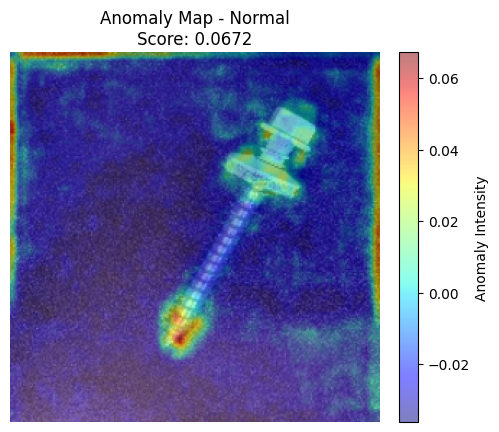

File: PXL_20250109_174818642.MP.jpg | Label: Anomalous | Anomaly Score: 0.0746


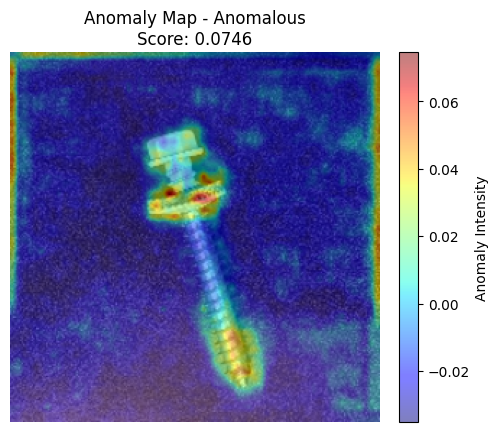

In [ ]:
test_dataset("screws", 5)

(18, 224, 224, 3)


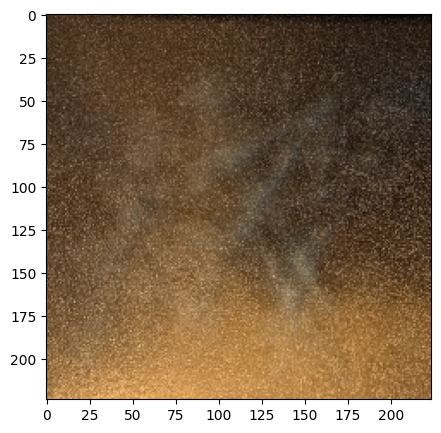

[0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0.01266274 0.01262501 0.01128812 0.01189333 0.01267228 0.01220351
 0.00899846 0.02623149 0.0070275  0.01327617 0.01168453 0.01184507
 0.01503672 0.01297135 0.01109155]
AUROC Score: 0.48
(17, 224, 224, 3)


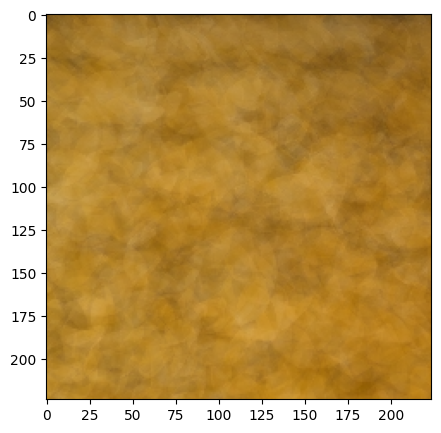

[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0.02781279 0.02871893 0.02962093 0.03351079 0.02817912 0.02717947
 0.02904834 0.03291886 0.02258807 0.03534515 0.02747697 0.02566343
 0.03082341 0.04285557 0.02779141 0.02496582]
AUROC Score: 0.4666666666666666


In [ ]:
# TODO use your class above as well as helper functions to generate your
# predictions on the datasets and evaluate the results.
def do_analysis(ad, class_name):
  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)
  ad.create_model(training_images)
  predictions = ad.predict(testing_images)
  basic_evaluation(predictions, testing_labels)

do_analysis(AnomalyDetector(), 'screws')
do_analysis(AnomalyDetector(), 'pasta')
